<a href="https://colab.research.google.com/github/sivapothula000/ML_Models/blob/main/DL_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SET -A


## Question 1

In [1]:
 import tensorflow as tf
# TensorFlow version
print("TensorFlow Version:", tf.__version__)
# List all physical devices
devices = tf.config.list_physical_devices()
print("All Devices:", devices)
# Check GPU
gpu = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpu)


TensorFlow Version: 2.19.0
All Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU Available: []


## Question 2


In [2]:
import tensorflow as tf
tensor = tf.constant([1,2,3,4,5])
# Only operation seed
print(tf.random.shuffle(tensor, seed=1))
print(tf.random.shuffle(tensor, seed=1))
# Using global seed
tf.random.set_seed(42)
print(tf.random.shuffle(tensor))
print(tf.random.shuffle(tensor))


tf.Tensor([3 5 1 4 2], shape=(5,), dtype=int32)
tf.Tensor([3 4 1 5 2], shape=(5,), dtype=int32)
tf.Tensor([3 1 5 4 2], shape=(5,), dtype=int32)
tf.Tensor([4 5 2 1 3], shape=(5,), dtype=int32)


## Question 3


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
Dense(4, activation='tanh', input_shape=(2,)),
Dense(2, activation='tanh'),
Dense(1, activation='sigmoid')
])
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

# SET-B

## Question 1

In [4]:
import numpy as np
# Create vector of first 24 integers
vector = np.arange(1,25)
print("Vector:")
print(vector)
# Convert to rank-3 tensor
tensor = vector.reshape(2,3,4)
print("Rank-3 Tensor:")
print(tensor)


Vector:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Rank-3 Tensor:
[[[ 1  2  3  4]
  [ 5  6  7  8]
  [ 9 10 11 12]]

 [[13 14 15 16]
  [17 18 19 20]
  [21 22 23 24]]]


## Question 2

In [5]:
import tensorflow as tf
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0
print("Normalized pixel range:", x_train.min(), x_train.max())


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)
Normalized pixel range: 0.0 1.0


## Question 3


In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

# Load dataset
data = fetch_california_housing()

X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

# Evaluation
print("Ridge R2 Score:", r2_score(y_test, ridge_pred))
print("Lasso R2 Score:", r2_score(y_test, lasso_pred))

Ridge R2 Score: 0.5758549611440138
Lasso R2 Score: 0.5318167610318159


# SET -C


## Question 1

In [8]:
import tensorflow as tf
# Generator with seed 42
g1 = tf.random.Generator.from_seed(42)
# Generator with seed 11
g2 = tf.random.Generator.from_seed(11)
# Generate Gaussian tensors
tensor1 = g1.normal(shape=(2,3))
tensor2 = g2.normal(shape=(2,3))
print("Tensor from seed 42:")
print(tensor1)
print("\nTensor from seed 11:")
print(tensor2)


Tensor from seed 42:
tf.Tensor(
[[-0.7565803  -0.06854702  0.07595026]
 [-1.2573844  -0.23193763 -1.8107855 ]], shape=(2, 3), dtype=float32)

Tensor from seed 11:
tf.Tensor(
[[ 0.27305737 -0.29925638 -0.3652325 ]
 [ 0.61883307 -1.0130816   0.28291714]], shape=(2, 3), dtype=float32)


## Question 2

In [9]:
import tensorflow as tf
# Create rank-2 tensor
tensor = tf.constant([[1,2], [3,4]])
print("Original Tensor:")
print(tensor)
print("Shape:", tensor.shape)
# Convert to rank-3 using newaxis
tensor_new = tensor[:,:,tf.newaxis]
print("\nConverted Tensor:")
print(tensor_new)
print("New Shape:", tensor_new.shape)


Original Tensor:
tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
Shape: (2, 2)

Converted Tensor:
tf.Tensor(
[[[1]
  [2]]

 [[3]
  [4]]], shape=(2, 2, 1), dtype=int32)
New Shape: (2, 2, 1)


## Question 3

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
# Input layer
inputs = Input(shape=(2,))
# Hidden layers
x = Dense(4, activation='tanh')(inputs)
x = Dense(2, activation='tanh')(x)
# Output layer
outputs = Dense(1, activation='sigmoid')(x)
# Create model
model = Model(inputs=inputs, outputs=outputs)
# Compile model
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
# Print model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

# SET - C


## Question 1

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization
from tensorflow.keras.layers import MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout
model = Sequential([
Conv2D(96,(11,11),strides=4,activation='relu',input_shape=(227,227,3)),
BatchNormalization(),
MaxPooling2D(pool_size=(3,3),strides=2),
Conv2D(256,(5,5),activation='relu'),
BatchNormalization(),
MaxPooling2D(pool_size=(3,3),strides=2),
Conv2D(384,(3,3),activation='relu'),
Conv2D(384,(3,3),activation='relu'),
Conv2D(256,(3,3),activation='relu'),
MaxPooling2D(pool_size=(3,3),strides=2),
Flatten(),
Dense(4096,activation='relu'),
Dropout(0.5),
Dense(4096,activation='relu'),
Dropout(0.5),
Dense(1000,activation='softmax')
])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 23, 23, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,825,320 (109.96 MB)

 Trainable params: 28,824,616 (109.96 MB)

 Non-trainable params: 704 (2.75 KB)

## Question 2(a)

In [12]:
import numpy as np
vocab = ["the","cat","sat","on","mat","dog","ran"]
sentence = [0,1,2,3,4]
def one_hot(idx,vocab_size):
    vec = np.zeros(vocab_size)
    vec[idx] = 1
    return vec
encoded = [one_hot(i,len(vocab)) for i in sentence]
matrix = np.array(encoded)
print(matrix)
print("Shape:",matrix.shape)


[[1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]]
Shape: (5, 7)


## Question 2(b)

In [13]:
import numpy as np
vocab = ["the","cat","sat","on","mat","dog","ran"]
sentence = [0,1,2,3,4]
np.random.seed(42)
E = np.random.randn(7,3)
print("Embedding Matrix:")
print(E)
embedded_sentence = E[sentence]
print("\nSentence Embeddings:")
print(embedded_sentence)
print("Shape:",embedded_sentence.shape)


Embedding Matrix:
[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733]
 [-0.90802408 -1.4123037   1.46564877]]

Sentence Embeddings:
[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783]]
Shape: (5, 3)


# SET - E


## Question 1

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0
# Reshape for CNN input
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)
# Create Data Generator
datagen = ImageDataGenerator(
rotation_range=10,
width_shift_range=0.1,
height_shift_range=0.1,
zoom_range=[0.9,1.1]
)
datagen.fit(x_train)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


## Question 2

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
model = Sequential([
Conv2D(filters=6, kernel_size=(5,5), activation='tanh', input_shape=(32,32,1)),
AveragePooling2D(pool_size=(2,2)),
Conv2D(filters=16, kernel_size=(5,5), activation='tanh'),
AveragePooling2D(pool_size=(2,2)),
Flatten(),
Dense(120, activation='tanh'),
Dense(84, activation='tanh'),
Dense(10, activation='softmax')
])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

## Question 3

In [16]:
import numpy as np
vocab = ["the", "cat", "sat", "on", "mat", "dog", "ran"]
sentence = [0,1,2,3,4]   # "the cat sat on mat"
EMBED_DIM = 3
# ---------- (a) One Hot Encoding ----------
def one_hot(idx, vocab_size):
    vec = np.zeros(vocab_size)
    vec[idx] = 1
    return vec
one_hot_matrix = np.array([one_hot(i,len(vocab)) for i in sentence])
print("One Hot Matrix:")
print(one_hot_matrix)
print("Shape:",one_hot_matrix.shape)

# ---------- (b) Embedding Lookup ----------
np.random.seed(42)
E = np.random.randn(len(vocab), EMBED_DIM)
embedding_sentence = E[sentence]
print("\nEmbedding Matrix:")
print(E)
print("\nSentence Embeddings:")
print(embedding_sentence)
print("Shape:",embedding_sentence.shape)

# ---------- (c) Matrix Multiplication ----------
embedding_from_onehot = np.dot(one_hot_matrix, E)
print("\nEmbedding from One Hot × Embedding Matrix:")
print(embedding_from_onehot)

# ---------- (d) Cosine Similarity ----------
def cosine_similarity(a,b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
# indices
cat_index = vocab.index("cat")
dog_index = vocab.index("dog")
# one-hot similarity
sim_onehot = cosine_similarity(one_hot(cat_index,len(vocab)),
                               one_hot(dog_index,len(vocab)))
# embedding similarity
sim_embed = cosine_similarity(E[cat_index],E[dog_index])
print("\nCosine Similarity (One Hot):",sim_onehot)
print("Cosine Similarity (Embedding):",sim_embed)


One Hot Matrix:
[[1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]]
Shape: (5, 7)

Embedding Matrix:
[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733]
 [-0.90802408 -1.4123037   1.46564877]]

Sentence Embeddings:
[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783]]
Shape: (5, 3)

Embedding from One Hot × Embedding Matrix:
[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783]]

Cosine Similarity (One Hot): 0.0
Cosine Similarity (Embedding): -0.3703193462598209

# SET - F

## Question 1

In [17]:
import numpy as np
y_true = np.array([1,0,1,1,0,0,1,0])
y_pred_prob = np.array([0.9,0.2,0.6,0.4,0.3,0.8,0.7,0.1])
# threshold
threshold = 0.5
# convert probabilities to predicted labels
y_pred = (y_pred_prob >= threshold).astype(int)
print("Predicted Labels:", y_pred)
# confusion matrix values
TP = np.sum((y_true==1) & (y_pred==1))
TN = np.sum((y_true==0) & (y_pred==0))
FP = np.sum((y_true==0) & (y_pred==1))
FN = np.sum((y_true==1) & (y_pred==0))
accuracy = (TP+TN)/(TP+TN+FP+FN)
precision = TP/(TP+FP)
recall = TP/(TP+FN)
f1 = 2*(precision*recall)/(precision+recall)
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)


Predicted Labels: [1 0 1 0 0 1 1 0]
Accuracy: 0.75
Precision: 0.75
Recall: 0.75
F1 Score: 0.75


## Question 2

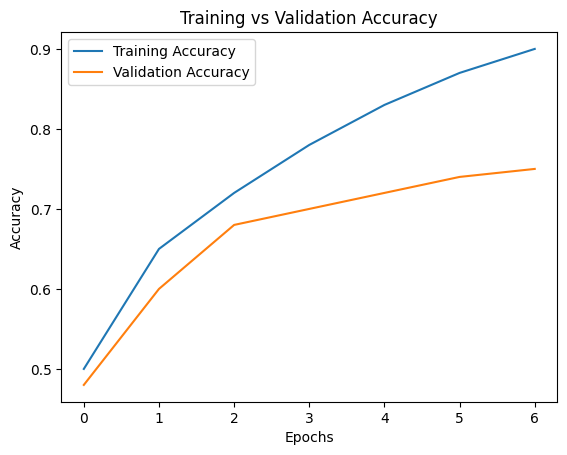

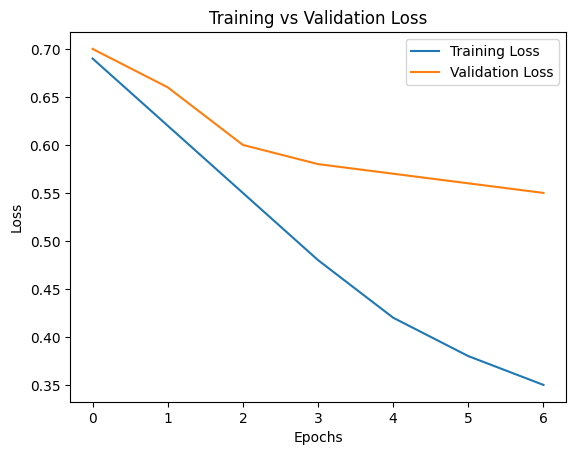

In [18]:
import matplotlib.pyplot as plt

class DummyHistory:
    def __init__(self):
        self.history = {
            'loss':[0.69,0.62,0.55,0.48,0.42,0.38,0.35],
            'accuracy':[0.50,0.65,0.72,0.78,0.83,0.87,0.90],
            'val_loss':[0.70,0.66,0.60,0.58,0.57,0.56,0.55],
            'val_accuracy':[0.48,0.60,0.68,0.70,0.72,0.74,0.75]
        }

history = DummyHistory()

# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


## Question 3

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
# Early Stopping
early_stop = EarlyStopping(
monitor='val_loss',
patience=3,
restore_best_weights=True
)

# Model Checkpoint
checkpoint = ModelCheckpoint(
'best_model.h5',
monitor='val_accuracy',
mode='max',
save_best_only=True
)
# CSV Logger
csv_logger = CSVLogger('training_log.csv')
callbacks = [early_stop, checkpoint, csv_logger]


# SET - G

Training Data Shape: (60000, 28, 28)
Test Data Shape: (10000, 28, 28)


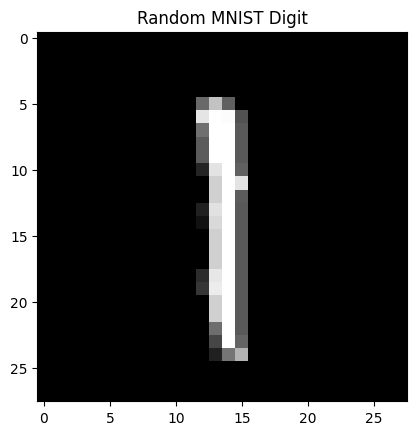

Image Shape: (28, 28)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 0, 0, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 0)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 84)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,626 (201.66 KB)

 Trainable params: 51,626 (201.66 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#Step 1: Load MNIST Dataset
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Training Data Shape:", x_train.shape)
print("Test Data Shape:", x_test.shape)
#Step 2: Take Random Image Sample
import random
index = random.randint(0, len(x_train)-1)
sample_image = x_train[index]
plt.imshow(sample_image, cmap='gray')
plt.title("Random MNIST Digit")
plt.show()
#Step 3: Display Image Size
print("Image Shape:", sample_image.shape)
#Step 4: Build LeNet Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense
model = Sequential([
Conv2D(filters=6, kernel_size=(5,5), strides=1,
activation='tanh', input_shape=(28,28,1)),
AveragePooling2D(pool_size=(2,2), strides=2),
Conv2D(filters=16, kernel_size=(5,5), strides=1,
activation='tanh'),
AveragePooling2D(pool_size=(2,2), strides=2),
Conv2D(filters=120, kernel_size=(5,5),
activation='tanh'),
Flatten(),
Dense(84, activation='tanh'),
Dense(10, activation='softmax')
])
#Step 5: Compile the Model
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
model.summary()


# SET - H

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (25000, 200)
Test shape: (25000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 269ms/step - accuracy: 0.7958 - loss: 0.4341 - val_accuracy: 0.8736 - val_loss: 0.3127
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 302ms/step - accuracy: 0.8971 - loss: 0.2719 - val_accuracy: 0.8612 - val_loss: 0.3236
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 280ms/step - accuracy: 0.9172 - loss: 0.2274 - val_accuracy: 0.8420 - val_loss: 0.3615
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 280ms/step - accuracy: 0.9187 - loss: 0.2183 - val_accuracy: 0.8676 - val_loss: 0.3767
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.9465 - loss: 0.1551 - val_accuracy: 0.8344 - val_loss: 0.4348


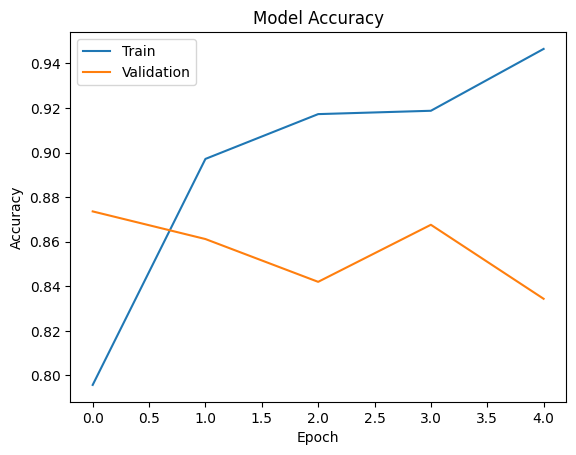

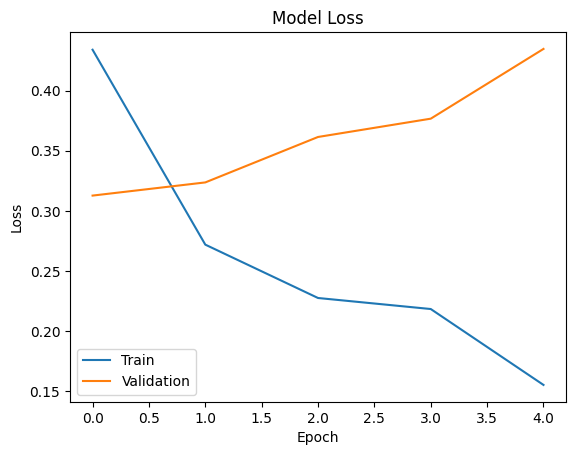

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
Predictions:
[[0.20855194]
 [0.999594  ]
 [0.56830156]
 [0.9313397 ]
 [0.99983466]
 [0.9383686 ]
 [0.97270095]
 [0.00139416]
 [0.8509453 ]
 [0.95051736]]


In [23]:
#Step 1: Load and Preprocess Dataset
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
vocab_size = 10000
max_len = 200
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)
print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)
#Step 2: Build the Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
Embedding(vocab_size, 100, input_length=200),
LSTM(64),
Dense(32, activation='relu'),
Dropout(0.5),
Dense(1, activation='sigmoid')
])
#Step 3: Compile Model
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
model.summary()
#Step 4: Train Model
history = model.fit(
x_train, y_train,
epochs=5,
batch_size=64,
validation_split=0.2
)
#Step 5: Plot Accuracy and Loss
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()
#Step 6: Predictions
import numpy as np
predictions = model.predict(x_test[:10])
print("Predictions:")
print(predictions)


# SET - I

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Data Shape: (50000, 32, 32, 3)
Test Data Shape: (10000, 32, 32, 3)


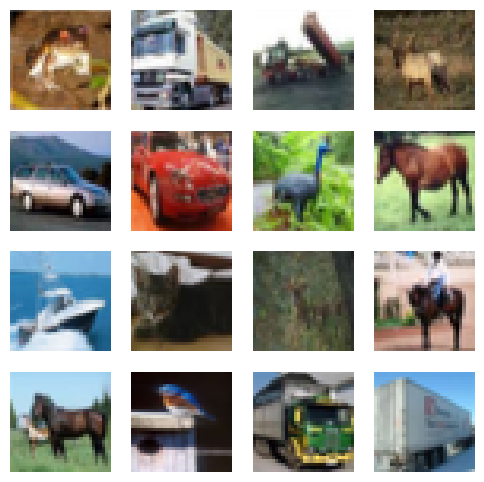

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 650s 518ms/step - Precision: 0.7090 - Recall: 0.3113 - accuracy: 0.5193 - loss: 1.3700 - val_Precision: 0.7157 - val_Recall: 0.3948 - val_accuracy: 0.5656 - val_loss: 1.2398
Epoch 2/5


KeyboardInterrupt: 

In [24]:
#Step 1: Load CIFAR-10 Dataset
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Data Shape:", x_train.shape)
print("Test Data Shape:", x_test.shape)
#Step 2: Normalize Dataset
x_train = x_train / 255.0
x_test = x_test / 255.0
#Step 3: Display Random Images (4×4 Grid)
plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')

plt.show()
#Step 4: Load VGG16 Model
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

base_model.trainable = False
#Step 5: Add Custom Layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])
#Step 6: Compile Model
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy','Precision','Recall']
)

model.summary()
#Step 7: Early Stopping Callback
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
monitor='val_loss',
patience=3,
restore_best_weights=True
)
#Step 8: Train Model
history = model.fit(
x_train,
tf.keras.utils.to_categorical(y_train),
validation_split=0.2,
epochs=5,
callbacks=[early_stop]
)
#Step 9: Plot Training and Validation Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()
#Step 10: Plot Training and Validation Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()
#Step 11: Test Accuracy
test_loss, test_acc, test_precision, test_recall = model.evaluate(
x_test,
tf.keras.utils.to_categorical(y_test)
)
print("Test Accuracy:", test_acc)


# SET - J

In [25]:
#Step 1: Load and Preprocess IMDB Dataset
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_features = 10000
max_len = 200
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=max_features)
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
#Step 2: Build Sequential RNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
model = Sequential([
Embedding(input_dim=max_features, output_dim=32, input_length=max_len),
SimpleRNN(32),
Dense(1, activation='sigmoid')
])
#Step 3: Compile the Model
model.compile(
optimizer='rmsprop',
loss='binary_crossentropy',
metrics=['accuracy']
)
model.summary()
#Step 4: Train the Model
history = model.fit(
x_train,
y_train,
epochs=5,
batch_size=64,
validation_split=0.2
)
#Step 5: Evaluate Model on Test Dataset
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


Training data shape: (25000, 200)
Test data shape: (25000, 200)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.6514 - loss: 0.6061 - val_accuracy: 0.7972 - val_loss: 0.4511
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.8323 - loss: 0.3868 - val_accuracy: 0.8196 - val_loss: 0.3957
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8821 - loss: 0.2951 - val_accuracy: 0.8432 - val_loss: 0.3668
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.9161 - loss: 0.2165 - val_accuracy: 0.7446 - val_loss: 0.5579
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9493 - loss: 0.1422 - val_accuracy: 0.8432 - val_loss: 0.4317
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8416 - loss: 0.4424
Test Loss: 0.44243356585502625
Test Accuracy: 0.8416000008583069
